# Sprint 2 – Exploratory Data Analysis & Visualization
## Stroke Prediction Analytics

### Sprint Goal
Discover meaningful patterns, trends, and relationships in the cleaned healthcare stroke dataset through statistical analysis, Pandas operations, visualization, and business storytelling.

**Dataset:** `cleaned healthcare_dataset.csv`


 1. Business Understanding

**Business problem:** Identify patient characteristics and health-related factors associated with stroke occurrence.

**Target variable:** `stroke`
- `0` = No stroke
- `1` = Stroke

**Business questions**
1. How imbalanced is the stroke target?
2. Which patient characteristics differ between stroke and non-stroke groups?



 2. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


 3. Load Dataset and Basic Understanding

In [ ]:
df = pd.read_csv("/content/cleaned healthcare_dataset")

print("Shape:", df.shape)
display(df.head())
display(df.info())


Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.600000,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.893237,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.500000,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.400000,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.000000,never smoked,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


None

In [ ]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Columns:
['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

Data types:


,0
id,int64
gender,object
age,float64
hypertension,int64
heart_disease,int64
ever_married,object
work_type,object
Residence_type,object
avg_glucose_level,float64
bmi,float64



Missing values:


,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0



Duplicate rows: 0


4. Descriptive Analysis

In [ ]:
#4.1 Numerical Summary

'''The numerical features are summarized using count, mean, standard deviation, minimum, quartiles, and maximum. These statistics help understand central tendency and dispersion.'''

numerical_features = ["age", "hypertension", "heart_disease", "avg_glucose_level", "bmi", "stroke"]
descriptive_stats = df[numerical_features].describe().T
descriptive_stats["median"] = df[numerical_features].median()
descriptive_stats["variance"] = df[numerical_features].var()
descriptive_stats["range"] = df[numerical_features].max() - df[numerical_features].min()
descriptive_stats["skewness"] = df[numerical_features].skew()
display(descriptive_stats)


,count,mean,std,min,25%,50%,75%,max,median,variance,range,skewness
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00,45.000,511.331792,81.92,-0.137059
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00,0.000,0.087976,1.00,2.715392
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00,0.000,0.051104,1.00,3.947244
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74,91.885,2050.600820,216.62,1.572284
bmi,5110.0,28.893237,7.698018,10.30,23.800,28.400,32.80,97.60,28.400,59.259478,87.30,1.076716
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00,0.000,0.046363,1.00,4.193284


**Interpretation:** Mean and median show the typical value of each numerical feature. Standard deviation and variance describe spread. Range shows the distance between minimum and maximum. Skewness indicates whether a distribution is symmetric or has a longer tail.


In [ ]:

#4.2 Central Tendency and Dispersion
central_tendency = pd.DataFrame({
    "Mean": df[numerical_features].mean(),
    "Median": df[numerical_features].median(),
    "Mode": df[numerical_features].mode().iloc[0]
})
dispersion = pd.DataFrame({
    "Std Dev": df[numerical_features].std(),
    "Variance": df[numerical_features].var(),
    "Range": df[numerical_features].max() - df[numerical_features].min()
})
display(central_tendency)
display(dispersion)


,Mean,Median,Mode
age,43.226614,45.000,78.000000
hypertension,0.097456,0.000,0.000000
heart_disease,0.054012,0.000,0.000000
avg_glucose_level,106.147677,91.885,93.880000
bmi,28.893237,28.400,28.893237
stroke,0.048728,0.000,0.000000


,Std Dev,Variance,Range
age,22.612647,511.331792,81.92
hypertension,0.296607,0.087976,1.00
heart_disease,0.226063,0.051104,1.00
avg_glucose_level,45.283560,2050.600820,216.62
bmi,7.698018,59.259478,87.30
stroke,0.215320,0.046363,1.00


 5. Univariate Analysis

In [ ]:
#5.1 Numerical Distributions
continuous = ["age", "avg_glucose_level", "bmi"]

for col in continuous:
    fig, ax = plt.subplots(figsize=(7,4))
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    plt.show()


In [ ]:
#5.2 Numerical Outlier View
for col in continuous:
    fig, ax = plt.subplots(figsize=(7,3.5))
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f"Box Plot of {col}")
    plt.show()


In [ ]:
#5.3 Categorical Frequencies
categorical_features = [
    "gender", "ever_married", "work_type",
    "Residence_type", "smoking_status", "hypertension",
    "heart_disease", "stroke"
]

for col in categorical_features:
    print(f"\n--- {col} ---")
    display(df[col].value_counts(dropna=False).to_frame("count"))
    display((df[col].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentage"))


In [ ]:
#5.4 Target Distribution
fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(data=df, x="stroke", ax=ax)
ax.set_title("Stroke Outcome Distribution")
ax.set_xlabel("Stroke")
ax.set_ylabel("Number of Patients")
plt.show()


 6. Bivariate Analysis

In [ ]:
#6.1 Numerical vs Numerical
# Correlation among continuous variables
display(df[continuous].corr())

fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(data=df, x="age", y="avg_glucose_level", hue="stroke", alpha=0.5, ax=ax)
ax.set_title("Age vs Average Glucose Level by Stroke")
plt.show()


In [ ]:
 #6.2 Numerical vs Categorical – Age and Stroke
fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(data=df, x="stroke", y="age", ax=ax)
ax.set_title("Age Distribution by Stroke Outcome")
plt.show()

display(df.groupby("stroke")["age"].agg(["count","mean","median","std","min","max"]))


In [ ]:
#6.3 Glucose and Stroke
fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(data=df, x="stroke", y="avg_glucose_level", ax=ax)
ax.set_title("Average Glucose Level by Stroke Outcome")
plt.show()

display(df.groupby("stroke")["avg_glucose_level"].agg(["count","mean","median","std","min","max"]))


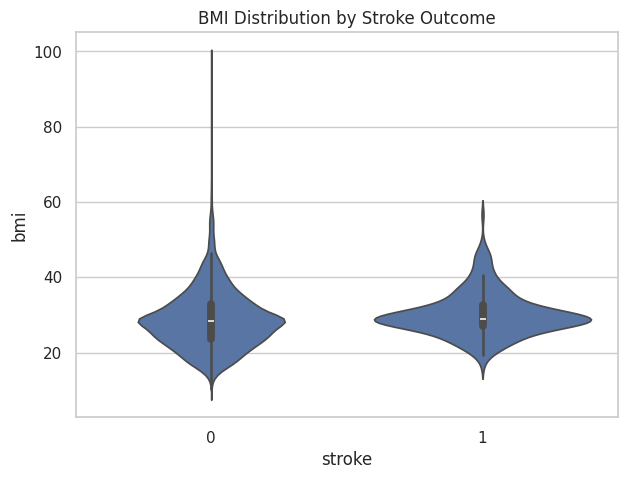

,count,mean,median,std,min,max
stroke,,,,,,
0,4861,28.825388,28.300000,7.776203,10.3,97.6
1,249,30.217789,28.893237,5.825589,16.9,56.6


In [ ]:
# 6.4 BMI and Stroke
fig, ax = plt.subplots(figsize=(7,5))
sns.violinplot(data=df, x="stroke", y="bmi", ax=ax)
ax.set_title("BMI Distribution by Stroke Outcome")
plt.show()

display(df.groupby("stroke")["bmi"].agg(["count","mean","median","std","min","max"]))


In [ ]:
cross_smoking = pd.crosstab(df["smoking_status"], df["stroke"], margins=True)
display(cross_smoking)

cross_hyper = pd.crosstab(df["hypertension"], df["stroke"], normalize="index") * 100
display(cross_hyper.round(2))


 7. Multivariate Analysis

In [ ]:
#7.1 Pair Plot
pair_cols = ["age", "avg_glucose_level", "bmi", "hypertension", "heart_disease", "stroke"]
sns.pairplot(df[pair_cols], hue="stroke", corner=True, plot_kws={"alpha":0.35})
plt.show()


In [ ]:
#7.2 Multivariate Risk Profile
risk_profile = df.groupby("stroke").agg(
    patients=("id","count"),
    avg_age=("age","mean"),
    avg_glucose=("avg_glucose_level","mean"),
    avg_bmi=("bmi","mean"),
    hypertension_rate=("hypertension","mean"),
    heart_disease_rate=("heart_disease","mean")
)
risk_profile["hypertension_rate"] *= 100
risk_profile["heart_disease_rate"] *= 100
display(risk_profile.round(2))


 8. Group-Based Analysis

In [ ]:
#8.1 Stroke Rate by Age Group
df["age_group"] = pd.cut(
    df["age"],
    bins=[-np.inf, 18, 40, 60, 75, np.inf],
    labels=["<=18", "19-40", "41-60", "61-75", "76+"]
)

age_group_summary = df.groupby("age_group", observed=False).agg(
    patients=("id","count"),
    strokes=("stroke","sum"),
    stroke_rate=("stroke","mean")
)
age_group_summary["stroke_rate"] *= 100
display(age_group_summary.round(2))


In [ ]:
#8.2 Stroke Rate by Smoking Status
smoking_summary = df.groupby("smoking_status", dropna=False).agg(
    patients=("id","count"),
    strokes=("stroke","sum"),
    stroke_rate=("stroke","mean")
)
smoking_summary["stroke_rate"] *= 100
display(smoking_summary.round(2))


In [ ]:
#8.3 Stroke Rate by Work Type
work_summary = df.groupby("work_type").agg(
    patients=("id","count"),
    strokes=("stroke","sum"),
    stroke_rate=("stroke","mean")
)
work_summary["stroke_rate"] *= 100
display(work_summary.round(2))


 9. Pivot Table Analysis

In [ ]:
#Pivot Table 1 – Stroke by Gender
pivot_gender = pd.pivot_table(
    df, index="gender", columns="stroke", values="id",
    aggfunc="count", fill_value=0
)
display(pivot_gender)


stroke,0,1
gender,,
Female,2853,141
Male,2007,108
Other,1,0


In [ ]:
#Pivot Table 2 – Stroke by Work Type
pivot_work = pd.pivot_table(
    df, index="work_type", columns="stroke", values="id",
    aggfunc="count", fill_value=0
)
display(pivot_work)


In [ ]:
#Pivot Table 3 – Stroke by Residence Type and Hypertension
pivot_residence_hyper = pd.pivot_table(
    df, index="Residence_type", columns="hypertension", values="stroke",
    aggfunc=["count","sum"], fill_value=0
)
display(pivot_residence_hyper)


 Pivot Table 4 – Mean Health Indicators by Stroke

In [ ]:
pivot_health = pd.pivot_table(
    df, index="stroke",
    values=["age","avg_glucose_level","bmi","hypertension","heart_disease"],
    aggfunc=["mean","median"]
)
display(pivot_health.round(2))


10. Crosstab Analysis

 Crosstab 1 Hypertension vs Stroke

In [ ]:
ct_hyper = pd.crosstab(df["hypertension"], df["stroke"], margins=True)
display(ct_hyper)
display(pd.crosstab(df["hypertension"], df["stroke"], normalize="index").mul(100).round(2))


Crosstab 2 – Heart Disease vs Stroke

In [ ]:
ct_heart = pd.crosstab(df["heart_disease"], df["stroke"], margins=True)
display(ct_heart)
display(pd.crosstab(df["heart_disease"], df["stroke"], normalize="index").mul(100).round(2))


 Crosstab 3 – Smoking Status vs Stroke

In [ ]:
ct_smoke = pd.crosstab(df["smoking_status"], df["stroke"], margins=True)
display(ct_smoke)
display(pd.crosstab(df["smoking_status"], df["stroke"], normalize="index").mul(100).round(2))


11. Correlation & Relationship Analysis

In [ ]:

#11.1 Correlation Matrix
corr_cols = ["age", "hypertension", "heart_disease", "avg_glucose_level", "bmi", "stroke"]
corr = df[corr_cols].corr()
display(corr.round(3))


In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap")
plt.show()


 11.2 Identify Strongest Relationships

In [ ]:
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(key=lambda s: s.abs(), ascending=False)
)
display(corr_pairs.to_frame("correlation").head(10))


12. Additional Visual Storytelling

 Business Question 1: How does stroke rate vary by age group?

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
age_group_summary["stroke_rate"].plot(kind="bar", ax=ax)
ax.set_title("Stroke Rate by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Stroke Rate (%)")
ax.tick_params(axis="x", rotation=0)
plt.show()


 Business Question 2: Which smoking categories have the highest observed stroke rate?

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
smoking_summary["stroke_rate"].sort_values(ascending=False).plot(kind="bar", ax=ax)
ax.set_title("Stroke Rate by Smoking Status")
ax.set_xlabel("Smoking Status")
ax.set_ylabel("Stroke Rate (%)")
ax.tick_params(axis="x", rotation=20)
plt.show()


Business Question 3: How do hypertension and heart disease jointly relate to stroke?

In [ ]:
joint = pd.crosstab(
    [df["hypertension"], df["heart_disease"]],
    df["stroke"],
    normalize="index"
) * 100
display(joint.round(2))

fig, ax = plt.subplots(figsize=(8,5))
joint[1].plot(kind="bar", ax=ax)
ax.set_title("Stroke Rate by Hypertension and Heart Disease Combination")
ax.set_xlabel("Hypertension, Heart Disease")
ax.set_ylabel("Stroke Rate (%)")
plt.show()


13. Key Business Insights

In [ ]:
# Automatically generate a compact set of dataset-specific metrics for the report
target_counts = df["stroke"].value_counts()
stroke_rate = df["stroke"].mean() * 100

print(f"Total patients: {len(df):,}")
print(f"Stroke cases: {int(target_counts.get(1,0)):,}")
print(f"Non-stroke cases: {int(target_counts.get(0,0)):,}")
print(f"Overall observed stroke rate: {stroke_rate:.2f}%")
print(f"Mean age (stroke=1): {df.loc[df.stroke==1,'age'].mean():.2f}")
print(f"Mean age (stroke=0): {df.loc[df.stroke==0,'age'].mean():.2f}")
print(f"Mean glucose (stroke=1): {df.loc[df.stroke==1,'avg_glucose_level'].mean():.2f}")
print(f"Mean glucose (stroke=0): {df.loc[df.stroke==0,'avg_glucose_level'].mean():.2f}")


14. Recommendations

Healthcare-Oriented Recommendations

- Use age, glucose, hypertension, heart disease, BMI, and smoking status as candidate risk-screening variables for further investigation.
- Prioritize risk assessment for patient groups with higher observed stroke rates, subject to clinical validation.
- Use class-imbalance-aware evaluation in future predictive modeling.
- Combine multiple risk factors rather than relying on a single variable.
- Treat EDA findings as associations that guide further analysis, not as medical diagnoses or causal conclusions.
- Validate any operational healthcare recommendation with qualified clinical professionals and appropriate statistical testing.


15. Sprint 2 Conclusion

The Sprint 2 EDA workflow examines the cleaned stroke dataset using descriptive statistics, univariate, bivariate, multivariate, group-based, pivot-table, crosstab, correlation, and visualization techniques. The analysis is designed to uncover meaningful patterns in patient demographics and health indicators and translate those patterns into business-oriented insights.

The findings provide a strong foundation for the next stage: statistical testing and/or predictive modeling for stroke-risk classification.
